In [1]:
import uproot
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [3]:
ROOT_FILE   = "../../../Data_Raw/Data_Basic_filter.root"
MODEL_PATH  = "../../../Bias/klasyfikator/trained/model-filter.pt"
SCALER_PATH = "../../../Bias/klasyfikator/trained/scaler_mlp1.pkl"
scaler = joblib.load(SCALER_PATH)

THRESH_MUON = 0.4   # prob < 0.4  → muon
THRESH_ELEC = 0.6   # prob > 0.6  → elektron

FEATURE_COLUMNS = [
    "track_TRTHits", "track_PixelHits", "track_SCTHits", "track_PixeldEdX",
    "topo_cluster_eta", "topo_cluster_phi", "topo_cluster_EM_prob",
    "topo_cluster_pt", "pt_ratio", "topo_cluster_lambda", "topo_cluster_lambda2"
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ── wczytanie danych ──────────────────────────────────────────────────────────
print("Wczytuję ROOT...")
with uproot.open(ROOT_FILE) as f:
    tree   = f["MLData"]
    all_branches = FEATURE_COLUMNS + ["inv_mass", "track_pt_sel", "track_eta_sel"]
    data   = tree.arrays(all_branches, library="np")

n_total = len(data["track_TRTHits"])
print(f"Wczytano {n_total} eventów")

Device: cuda
Wczytuję ROOT...
Wczytano 302451 eventów


In [4]:


# ── filtracja wartości sentinel ───────────────────────────────────────────────
mask_valid = np.ones(n_total, dtype=bool)
for col in FEATURE_COLUMNS:
    arr = data[col]
    mask_valid &= (arr != -1.0) & (arr != -10.0) & (arr != -999.0)

print(f"Po filtracji sentinel: {mask_valid.sum()} eventów")

X_feat   = np.column_stack([data[c][mask_valid] for c in FEATURE_COLUMNS]).astype(np.float32)
inv_mass  = data["inv_mass"][mask_valid]
track_pt  = data["track_pt_sel"][mask_valid]
track_eta = data["track_eta_sel"][mask_valid]
pt_ratio  = data["pt_ratio"][mask_valid]

# ── skalowanie i inferencja ───────────────────────────────────────────────────
print("Ładuję scaler i model...")
scaler = joblib.load(SCALER_PATH)
X_scaled = scaler.transform(X_feat)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=DEVICE)

model = torch.jit.load(MODEL_PATH, map_location=DEVICE)
model.eval()

print("Inferencja...")
with torch.no_grad():
    prob = torch.sigmoid(model(X_tensor)[:, 0]).cpu().numpy()

# ── podział na klasy ──────────────────────────────────────────────────────────
mask_mu = prob < THRESH_MUON
mask_el = prob > THRESH_ELEC
mask_dead = ~mask_mu & ~mask_el

print(f"Miony:         {mask_mu.sum()}")
print(f"Elektrony:     {mask_el.sum()}")
print(f"Strefa martwa: {mask_dead.sum()}")


Po filtracji sentinel: 241066 eventów
Ładuję scaler i model...
Inferencja...
Miony:         181466
Elektrony:     55274
Strefa martwa: 4326


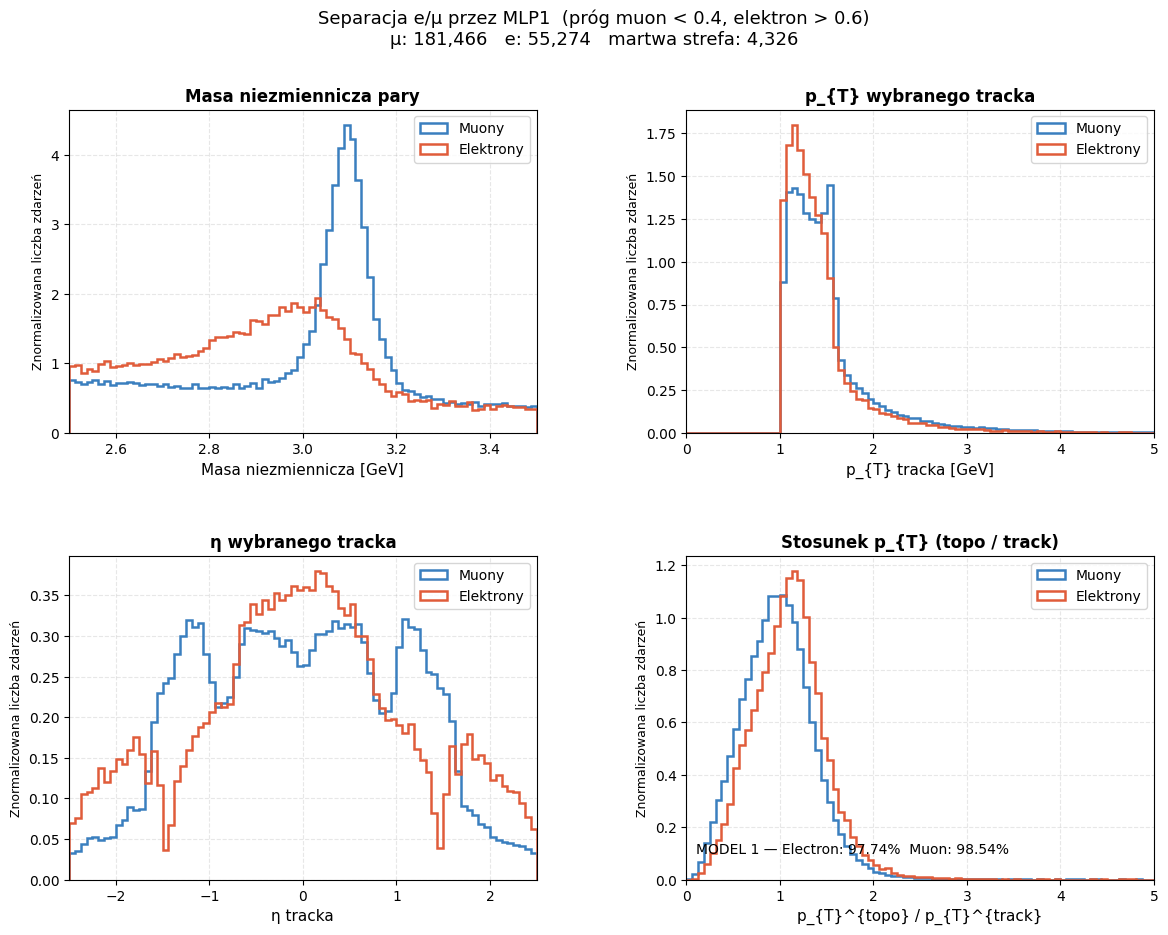

Zapisano: plot_mlp1_separation.png


In [5]:
# ── rysowanie ─────────────────────────────────────────────────────────────────
COLOR_MU = "#3A7FBF"
COLOR_EL = "#E05C3A"
ALPHA     = 0.7
BINS      = 80

def norm_hist(ax, data_mu, data_el, bins, xlabel, title, xrange=None):
    """Rysuje znormalizowane histogramy muonów i elektronów na jednej osi."""
    rng = xrange if xrange else (
        min(data_mu.min(), data_el.min()),
        max(data_mu.max(), data_el.max())
    )
    kw = dict(bins=bins, range=rng, histtype="step", linewidth=1.8, density=True)
    ax.hist(data_mu, color=COLOR_MU, label="Muony",    **kw)
    ax.hist(data_el, color=COLOR_EL, label="Elektrony", **kw)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Znormalizowana liczba zdarzeń", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_xlim(rng)


fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f"Separacja e/μ przez MLP1  "
    f"(próg muon < {THRESH_MUON}, elektron > {THRESH_ELEC})\n"
    f"μ: {mask_mu.sum():,}   e: {mask_el.sum():,}   martwa strefa: {mask_dead.sum():,}",
    fontsize=13, y=0.98
)

gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 1. Masa niezmiennicza
norm_hist(ax1,
          inv_mass[mask_mu], inv_mass[mask_el],
          bins=BINS, xlabel="Masa niezmiennicza [GeV]",
          title="Masa niezmiennicza pary",
          xrange=(2.5, 3.5))

# 2. pT wybranego tracka
norm_hist(ax2,
          track_pt[mask_mu], track_pt[mask_el],
          bins=BINS, xlabel="p_{T} tracka [GeV]",
          title="p_{T} wybranego tracka",
          xrange=(0.0, 5.0))

# 3. eta wybranego tracka
norm_hist(ax3,
          track_eta[mask_mu], track_eta[mask_el],
          bins=BINS, xlabel="η tracka",
          title="η wybranego tracka",
          xrange=(-2.5, 2.5))

# 4. pt_ratio (topo_cluster_pt / track_pt)
norm_hist(ax4,
          pt_ratio[mask_mu], pt_ratio[mask_el],
          bins=BINS, xlabel="p_{T}^{topo} / p_{T}^{track}",
          title="Stosunek p_{T} (topo / track)",
          xrange=(0.0, 5.0))

plt.savefig("plot_mlp1_separation.png", dpi=150, bbox_inches="tight")
plt.text(0.1,0.1,"MODEL 1 — Electron: 97.74%  Muon: 98.54%",size=10)
plt.show()
print("Zapisano: plot_mlp1_separation.png")